# Figure 1: 3D Clustering Scatter Plot
## AD Subtyping via PCA → UMAP → K-means

**Brain region**: BM_36 (Parahippocampal Gyrus / 海马旁回)

**Author**: 吴彦弘

**Pipeline**: Load data → Variance filtering (top 3000 HVGs) → PCA (50 PCs)
→ Determine optimal K (elbow + silhouette) → K-means (on PCA space)
→ UMAP (3D, visualization only) → Interactive 3D scatter plot

In [1]:
import sys
from pathlib import Path

# Ensure project root is on path for imports
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import DATA_PROCESSED, FIGURES_DIR, RANDOM_SEED
from src.analysis.clustering import (
    load_expression_matrix,
    load_sample_metadata,
    clean_metadata_for_analysis,
    filter_high_variance_genes,
    prepare_for_sklearn,
    run_pca,
    run_umap,
    run_kmeans,
    determine_optimal_k,
)
from src.visualization.scatter3d import plot_3d_clusters, plot_multi_view_comparison

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {FIGURES_DIR}")
print(f"Random seed: {RANDOM_SEED}")
print("\nAll imports successful.")

Project root: E:\大数据分析实践
Output directory: E:\大数据分析实践\outputs\figures
Random seed: 42

All imports successful.


## 1. Load & Clean Data

In [2]:
# Load expression matrix (genes x samples)
expr_path = DATA_PROCESSED / "BM_36_logcpm_matrix.csv"
meta_path = DATA_PROCESSED / "BM_36_sample_metadata.csv"

print("Loading expression matrix...")
expr = load_expression_matrix(expr_path)
print(f"Expression matrix: {expr.shape[0]:,} genes × {expr.shape[1]} samples")
print(f"Memory: {expr.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print("\nLoading sample metadata...")
meta = load_sample_metadata(meta_path)
print(f"Metadata: {meta.shape[0]} samples × {meta.shape[1]} columns")
print(f"Columns: {list(meta.columns)}")

# Verify sample ID alignment
assert (expr.columns == meta.index).all(), "Sample ID mismatch between expression and metadata!"
print("\n✓ Sample IDs aligned between expression matrix and metadata.")

# Clean metadata
meta_clean = clean_metadata_for_analysis(meta)
print(f"\nCleaned metadata. ageDeath range: {meta_clean['ageDeath'].min():.0f} - {meta_clean['ageDeath'].max():.0f}")
print(f"APOE missing: {meta_clean['apoeGenotype'].isna().sum()}/{len(meta_clean)} ({meta_clean['apoeGenotype'].isna().mean()*100:.1f}%)")
print(f"APOE genotype distribution:\n{meta_clean['apoeGenotype_str'].value_counts().to_string()}")

# Quick clinical summary
print(f"\nClinical score summary:")
print(meta_clean[["CDR", "Braak", "CERAD", "ageDeath"]].describe().round(2).to_string())

Loading expression matrix...
Expression matrix: 48,553 genes × 215 samples
Memory: 43.2 MB

Loading sample metadata...
Metadata: 215 samples × 12 columns
Columns: ['brain_area', 'specimen_key', 'individualID', 'has_clinical', 'sex', 'race', 'ageDeath', 'apoeGenotype', 'pmi', 'CERAD', 'Braak', 'CDR']

✓ Sample IDs aligned between expression matrix and metadata.

Cleaned metadata. ageDeath range: 61 - 90
APOE missing: 80/215 (37.2%)
APOE genotype distribution:
apoeGenotype_str
Unknown    80
ε3/ε3      76
ε3/ε4      37
ε2/ε3      16
ε4/ε4       3
ε2/ε2       2
ε2/ε4       1

Clinical score summary:
          CDR   Braak   CERAD  ageDeath
count  215.00  215.00  215.00     215.0
mean     2.18    3.72    2.07      83.1
std      1.68    1.92    0.97       7.6
min      0.00    0.00    1.00      61.0
25%      0.50    2.00    1.00      78.5
50%      2.00    4.00    2.00      85.0
75%      3.00    6.00    3.00      90.0
max      5.00    6.00    4.00      90.0


## 2. Variance Filtering

In [3]:
N_TOP_GENES = 3000
VAR_THRESHOLD = 0.1

print(f"Filtering genes: top {N_TOP_GENES} by variance → VarianceThreshold({VAR_THRESHOLD})...")
expr_filtered, selected_genes = filter_high_variance_genes(
    expr, n_top=N_TOP_GENES, variance_threshold=VAR_THRESHOLD
)
print(f"Retained {len(selected_genes):,} genes out of {expr.shape[0]:,}")

# Show top 10 most variable genes
variances = expr_filtered.var(axis=1).sort_values(ascending=False)
print(f"\nTop 10 most variable genes:")
for gene, var in variances.head(10).items():
    print(f"  {gene}: variance = {var:.4f}")

# Transpose for sklearn (genes × samples → samples × genes)
X = prepare_for_sklearn(expr_filtered)
print(f"\nSklearn-ready matrix: {X.shape} (samples × genes)")
print(f"Memory: {X.nbytes / 1024**2:.2f} MB, dtype: {X.dtype}")
print(f"Value range: [{X.min():.2f}, {X.max():.2f}]")

Filtering genes: top 3000 by variance → VarianceThreshold(0.1)...
Retained 3,000 genes out of 48,553

Top 10 most variable genes:
  ENSG00000229807: variance = 17.3068
  ENSG00000114374: variance = 12.6347
  ENSG00000012817: variance = 10.2774
  ENSG00000067048: variance = 9.9207
  ENSG00000183878: variance = 9.7613
  ENSG00000237973: variance = 8.9534
  ENSG00000165246: variance = 8.3964
  ENSG00000131002: variance = 8.1658
  ENSG00000129824: variance = 6.6877
  ENSG00000067646: variance = 6.0211

Sklearn-ready matrix: (215, 3000) (samples × genes)
Memory: 2.46 MB, dtype: float32
Value range: [0.00, 14.84]


## 3. PCA Dimensionality Reduction

Running PCA (n_components=50)...
Cumulative variance explained by 50 PCs: 88.82%
PC1 alone explains: 30.14%
PC1-5 explain: 61.30%
PC1-10 explain: 72.29%


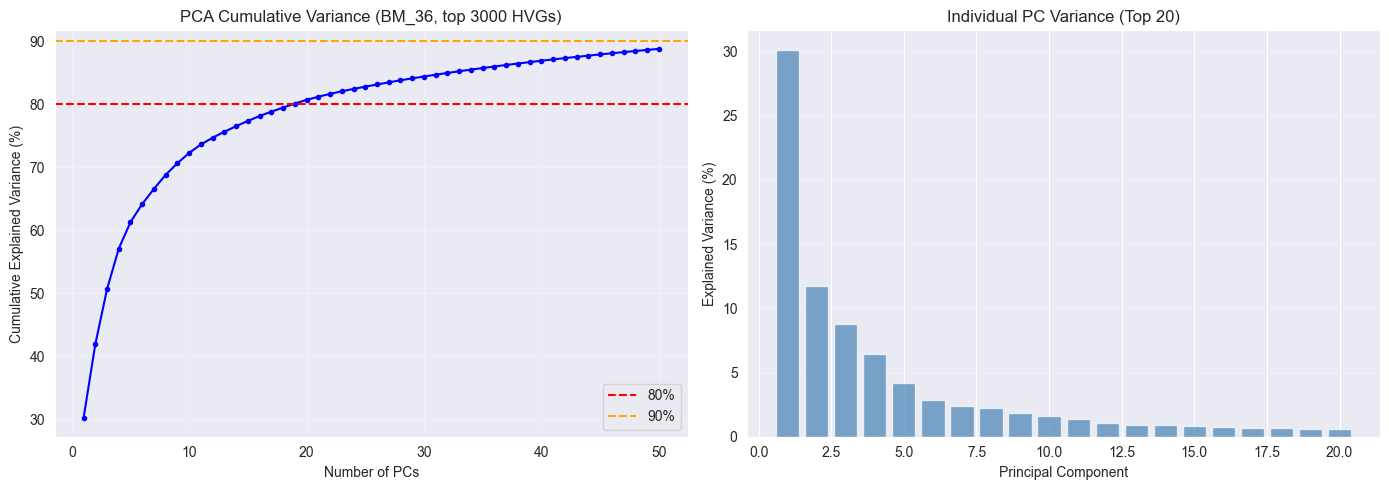

In [4]:
N_PC = 50

print(f"Running PCA (n_components={N_PC})...")
X_pca, pca_model = run_pca(X, n_components=N_PC)

# Explained variance diagnostics
cumsum_var = np.cumsum(pca_model.explained_variance_ratio_)
print(f"Cumulative variance explained by {N_PC} PCs: {cumsum_var[-1]:.2%}")
print(f"PC1 alone explains: {pca_model.explained_variance_ratio_[0]:.2%}")
print(f"PC1-5 explain: {cumsum_var[4]:.2%}")
print(f"PC1-10 explain: {cumsum_var[9]:.2%}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative variance
ax1.plot(range(1, N_PC+1), cumsum_var * 100, "b-o", markersize=3)
ax1.axhline(y=80, color="r", linestyle="--", label="80%")
ax1.axhline(y=90, color="orange", linestyle="--", label="90%")
ax1.set_xlabel("Number of PCs")
ax1.set_ylabel("Cumulative Explained Variance (%)")
ax1.set_title(f"PCA Cumulative Variance (BM_36, top {N_TOP_GENES} HVGs)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: individual variance
ax2.bar(range(1, 21), pca_model.explained_variance_ratio_[:20] * 100, color="steelblue", alpha=0.7)
ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Explained Variance (%)")
ax2.set_title("Individual PC Variance (Top 20)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 4. Determine Optimal Number of Clusters (K)

Determining optimal K over range [2, 3, 4, 5, 6, 7, 8]...
(This may take ~30-60 seconds)



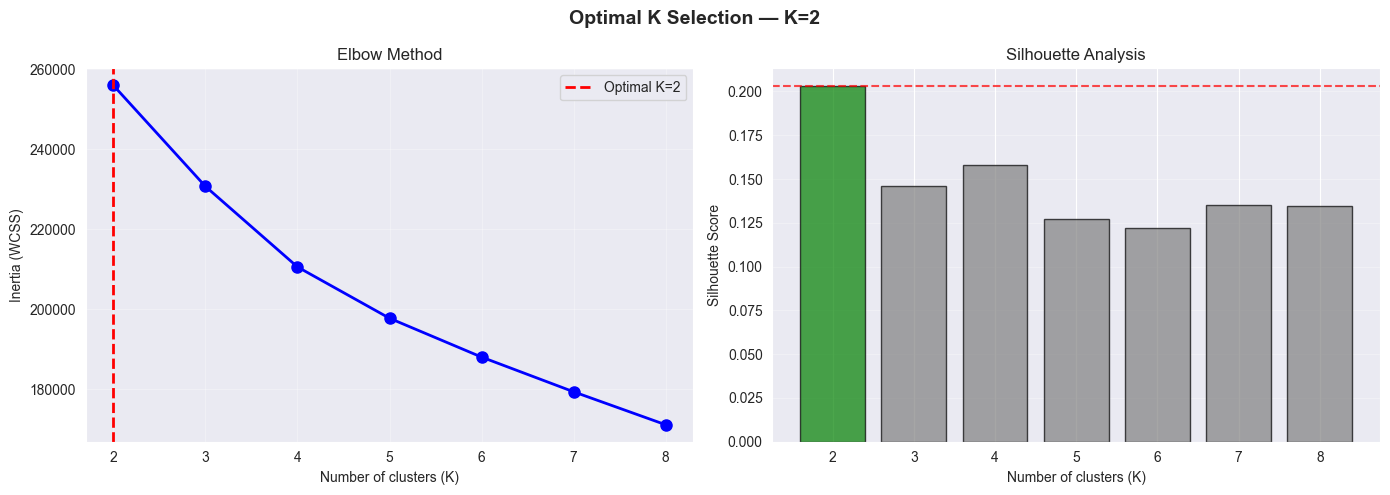


Metrics table:
 k       inertia  silhouette_score
 2 255940.390625          0.202999
 3 230667.859375          0.145982
 4 210526.937500          0.158225
 5 197695.406250          0.127152
 6 187979.718750          0.122083
 7 179303.484375          0.135124
 8 171059.203125          0.134453

>>> Recommended K = 2
    Silhouette score = 0.2030
    Inertia = 255940.39


In [5]:
K_RANGE = range(2, 9)

print(f"Determining optimal K over range {list(K_RANGE)}...")
print("(This may take ~30-60 seconds)\n")

optimal_k, k_metrics = determine_optimal_k(X_pca, k_range=K_RANGE)

# Diagnostic plot: elbow + silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(k_metrics["k"], k_metrics["inertia"], "b-o", markersize=8, linewidth=2)
ax1.axvline(x=optimal_k, color="r", linestyle="--", linewidth=2, label=f"Optimal K={optimal_k}")
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method")
ax1.set_xticks(list(K_RANGE))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette
colors = ["green" if k == optimal_k else "gray" for k in k_metrics["k"]]
ax2.bar(k_metrics["k"], k_metrics["silhouette_score"], color=colors, alpha=0.7, edgecolor="black")
ax2.axhline(y=k_metrics["silhouette_score"].max(), color="r", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.set_xlabel("Number of clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.set_xticks(list(K_RANGE))
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Optimal K Selection — K={optimal_k}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nMetrics table:")
print(k_metrics.to_string(index=False))
print(f"\n>>> Recommended K = {optimal_k}")
print(f"    Silhouette score = {k_metrics.loc[k_metrics['k']==optimal_k, 'silhouette_score'].values[0]:.4f}")
print(f"    Inertia = {k_metrics.loc[k_metrics['k']==optimal_k, 'inertia'].values[0]:.2f}")

## 5. K-means Clustering

In [6]:
print(f"Running K-means with K={optimal_k}...")
labels, kmeans_model = run_kmeans(X_pca, n_clusters=optimal_k)

# Cluster sizes
unique, counts = np.unique(labels, return_counts=True)
print("\nCluster sizes:")
for k, c in zip(unique, counts):
    print(f"  Subtype {k}: {c:3d} samples ({c/len(labels)*100:5.1f}%)")

# Attach cluster labels to metadata
meta_clean["Cluster"] = labels.astype(str)

# Clinical score distribution per cluster
print("\nMean clinical scores per cluster:")
cluster_clinical = meta_clean.groupby("Cluster")[["CDR", "Braak", "CERAD", "ageDeath"]].mean().round(2)
cluster_clinical["n"] = meta_clean.groupby("Cluster").size()
print(cluster_clinical.to_string())

# Cross-tab: Cluster × CDR
print("\nCluster × CDR cross-tabulation:")
ct = pd.crosstab(meta_clean["Cluster"], meta_clean["CDR"], margins=True)
print(ct.to_string())

# Cross-tab: Cluster × Braak
print("\nCluster × Braak cross-tabulation:")
ct2 = pd.crosstab(meta_clean["Cluster"], meta_clean["Braak"], margins=True)
print(ct2.to_string())

Running K-means with K=2...

Cluster sizes:
  Subtype 0: 119 samples ( 55.3%)
  Subtype 1:  96 samples ( 44.7%)

Mean clinical scores per cluster:
          CDR  Braak  CERAD  ageDeath    n
Cluster                                   
0        1.53   3.02   2.02     81.74  119
1        2.99   4.59   2.14     84.78   96

Cluster × CDR cross-tabulation:
CDR      0.0  0.5  1.0  2.0  3.0  4.0  5.0  All
Cluster                                        
0         27   27   16   20   13    7    9  119
1          5    5    8   12   29   19   18   96
All       32   32   24   32   42   26   27  215

Cluster × Braak cross-tabulation:
Braak    0.0  1.0  2.0  3.0  4.0  5.0  6.0  All
Cluster                                        
0          8   19   27   23   12   11   19  119
1          1    4    7   16   10   13   45   96
All        9   23   34   39   22   24   64  215


## 6. UMAP for 3D Visualization

Running UMAP for 3D visualization...
(This may take ~30-60 seconds)



E:\大数据分析实践\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (215, 3)
UMAP range per axis:
  UMAP1: [2.90, 7.83]
  UMAP2: [1.12, 8.34]
  UMAP3: [6.86, 12.53]


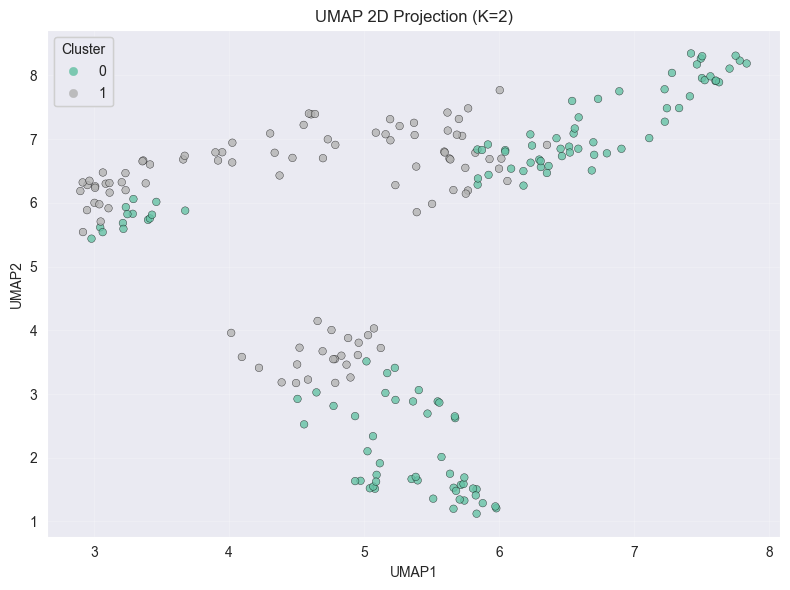

In [7]:
print("Running UMAP for 3D visualization...")
print("(This may take ~30-60 seconds)\n")

embedding_3d, umap_model = run_umap(X_pca)

print(f"UMAP embedding shape: {embedding_3d.shape}")
print(f"UMAP range per axis:")
for i in range(3):
    print(f"  UMAP{i+1}: [{embedding_3d[:, i].min():.2f}, {embedding_3d[:, i].max():.2f}]")

# Quick 2D sanity check: first two UMAP components colored by cluster
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    embedding_3d[:, 0], embedding_3d[:, 1],
    c=labels.astype(int), cmap="Set2", s=30, alpha=0.8, edgecolors="black", linewidth=0.3
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title(f"UMAP 2D Projection (K={optimal_k})")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend1)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Interactive 3D Scatter Plot

In [8]:
HOVER_COLS = ["individualID", "ageDeath", "apoeGenotype_str", "CERAD", "sex"]

fig = plot_3d_clusters(
    umap_emb=embedding_3d,
    labels=labels,
    metadata=meta_clean,
    symbol_col="CDR",
    size_col="Braak",
    hover_data=HOVER_COLS,
    marker_size=5,
    marker_opacity=0.85,
)

# Display in notebook
fig.show()

## 8. Multi-View Comparison

Same 3D UMAP layout, side-by-side views colored by Cluster, CERAD, Braak, and APOE genotype.


In [ ]:
fig_mv = plot_multi_view_comparison(
    umap_emb=embedding_3d,
    labels=labels,
    metadata=meta_clean,
    marker_size=3,
    marker_opacity=0.8,
)

fig_mv.show()

# Save multi-view HTML
mv_path = FIGURES_DIR / "fig1_multi_view_comparison.html"
fig_mv.write_html(mv_path)
print(f"✓ Saved multi-view comparison: {mv_path}")
print(f"  File size: {mv_path.stat().st_size / 1024:.1f} KB")


## 9. Save Outputs

In [9]:
# 1. Save interactive HTML figure
html_path = FIGURES_DIR / "fig1_3d_clustering_scatter.html"
fig.write_html(html_path)
print(f"✓ Saved interactive figure: {html_path}")
print(f"  File size: {html_path.stat().st_size / 1024:.1f} KB")

# 2. Save cluster labels with UMAP coordinates
labels_df = pd.DataFrame({
    "sample_id": meta_clean.index,
    "cluster": labels,
    "UMAP1": embedding_3d[:, 0],
    "UMAP2": embedding_3d[:, 1],
    "UMAP3": embedding_3d[:, 2],
})
labels_path = FIGURES_DIR / "BM_36_cluster_labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"✓ Saved cluster labels: {labels_path}")
print(f"  {len(labels_df)} samples, columns: {list(labels_df.columns)}")

# 3. Save K selection metrics
metrics_path = FIGURES_DIR / "BM_36_k_selection_metrics.csv"
k_metrics.to_csv(metrics_path, index=False)
print(f"✓ Saved K selection metrics: {metrics_path}")

# 4. Save PCA explained variance for report
pca_var_df = pd.DataFrame({
    "PC": range(1, N_PC + 1),
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_model.explained_variance_ratio_),
})
pca_var_path = FIGURES_DIR / "BM_36_pca_variance.csv"
pca_var_df.to_csv(pca_var_path, index=False)
print(f"✓ Saved PCA variance: {pca_var_path}")

print(f"\nAll outputs saved.")

✓ Saved interactive figure: E:\大数据分析实践\outputs\figures\fig1_3d_clustering_scatter.html
  File size: 4768.8 KB
✓ Saved cluster labels: E:\大数据分析实践\data\processed\BM_36_cluster_labels.csv
  215 samples, columns: ['sample_id', 'cluster', 'UMAP1', 'UMAP2', 'UMAP3']
✓ Saved K selection metrics: E:\大数据分析实践\data\processed\BM_36_k_selection_metrics.csv
✓ Saved PCA variance: E:\大数据分析实践\data\processed\BM_36_pca_variance.csv

All outputs saved.


## 10. Cluster Summary

In [10]:
# Comprehensive cluster summary table
summary = meta_clean.groupby("Cluster").agg(
    n_samples=("individualID", "count"),
    mean_CDR=("CDR", "mean"),
    median_CDR=("CDR", "median"),
    mean_Braak=("Braak", "mean"),
    median_Braak=("Braak", "median"),
    mean_CERAD=("CERAD", "mean"),
    mean_ageDeath=("ageDeath", "mean"),
    apoe_e4_carriers=("apoeGenotype", lambda x: (x.isin([34.0, 44.0, 24.0])).sum()),
    apoe_unknown=("apoeGenotype", lambda x: x.isna().sum()),
    female_pct=("sex", lambda x: (x == "female").mean() * 100),
).round(2)

summary["pct"] = (summary["n_samples"] / len(meta_clean) * 100).round(1)
summary["apoe_e4_pct"] = (summary["apoe_e4_carriers"] / (summary["n_samples"] - summary["apoe_unknown"]) * 100).round(1)

# Reorder columns
summary = summary[["n_samples", "pct", "mean_CDR", "median_CDR", "mean_Braak", "median_Braak",
                     "mean_CERAD", "mean_ageDeath", "female_pct", "apoe_e4_carriers", "apoe_e4_pct", "apoe_unknown"]]

print(f"Cluster Summary (K={optimal_k})\n")
print(f"Total samples: {len(meta_clean)}\n")
print(summary.to_string())

# Interpretation hint
print("\n--- Interpretation Guide ---")
print("CDR: 0=normal, 0.5=very mild, 1=mild, 2=moderate, 3=severe")
print("Braak: 0=none, I-II=transentorhinal, III-IV=limbic, V-VI=isocortical")
print("CERAD: 1=sparse, 2=moderate, 3=frequent, 4=severe (neuritic plaques)")
print("APOE ε4: major genetic risk factor for late-onset AD")

Cluster Summary (K=2)

Total samples: 215

         n_samples   pct  mean_CDR  median_CDR  mean_Braak  median_Braak  mean_CERAD  mean_ageDeath  female_pct  apoe_e4_carriers  apoe_e4_pct  apoe_unknown
Cluster                                                                                                                                                     
0              119  55.3      1.53         1.0        3.02           3.0        2.02          81.74       55.46                21         28.4            45
1               96  44.7      2.99         3.0        4.59           5.0        2.14          84.78       69.79                20         32.8            35

--- Interpretation Guide ---
CDR: 0=normal, 0.5=very mild, 1=mild, 2=moderate, 3=severe
Braak: 0=none, I-II=transentorhinal, III-IV=limbic, V-VI=isocortical
CERAD: 1=sparse, 2=moderate, 3=frequent, 4=severe (neuritic plaques)
APOE ε4: major genetic risk factor for late-onset AD


## 11. Validation: Clinical Score Distributions by Cluster

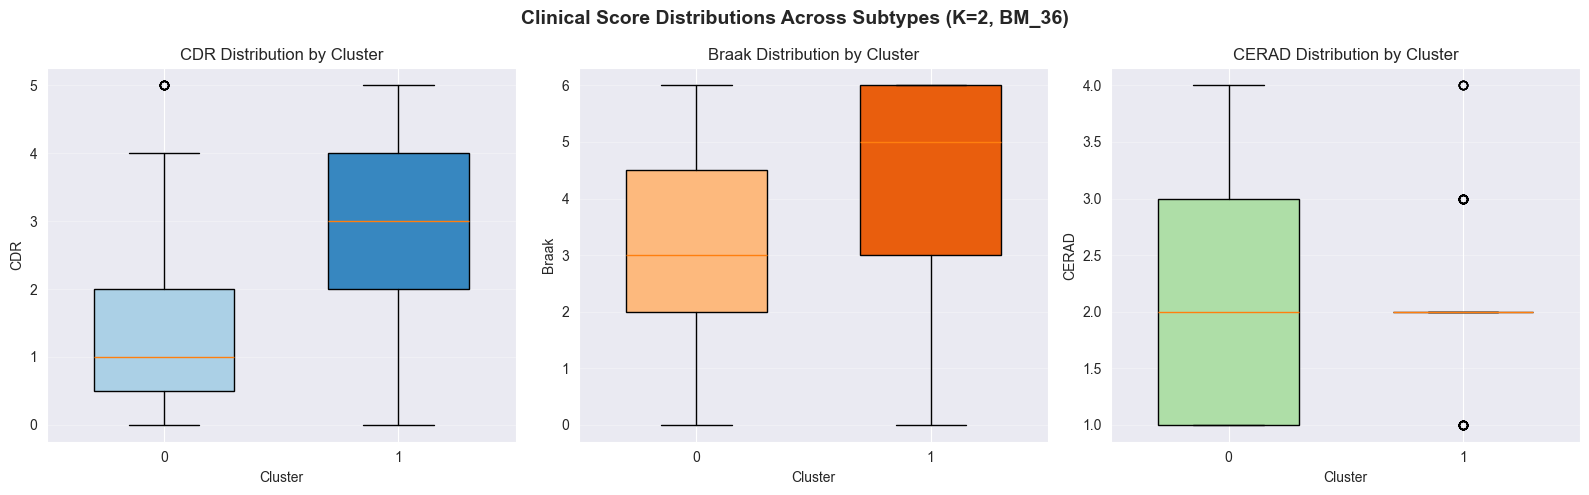


Kruskal-Wallis H-test (non-parametric ANOVA):
  CDR: H=41.75, p=1.04e-10 ***
  Braak: H=36.37, p=1.63e-09 ***
  CERAD: H=4.38, p=3.64e-02 *

✓ Analysis complete.


In [11]:
# Boxplots of clinical scores by cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, palette_name in zip(
    axes,
    ["CDR", "Braak", "CERAD"],
    ["Blues", "Oranges", "Greens"]
):
    data_by_cluster = [meta_clean.loc[meta_clean["Cluster"] == str(c), col].dropna().values
                       for c in sorted(meta_clean["Cluster"].unique())]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"], sns.color_palette(palette_name, len(data_by_cluster))):
        patch.set_facecolor(color)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)
    ax.set_title(f"{col} Distribution by Cluster")
    ax.set_xticklabels(sorted(meta_clean["Cluster"].unique()))
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Clinical Score Distributions Across Subtypes (K={optimal_k}, BM_36)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Kruskal-Wallis test
from scipy import stats
print("\nKruskal-Wallis H-test (non-parametric ANOVA):")
for col in ["CDR", "Braak", "CERAD"]:
    groups = [meta_clean.loc[meta_clean["Cluster"] == str(c), col].dropna().values
              for c in sorted(meta_clean["Cluster"].unique())]
    h_stat, p_val = stats.kruskal(*groups)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"  {col}: H={h_stat:.2f}, p={p_val:.2e} {sig}")

print("\n✓ Analysis complete.")

## 11. Clinical Validation: Chi-Square Tests

Assess whether subtypes have statistically significant clinical meaning
by testing associations with CERAD (plaque), Braak (tangle), CDR (dementia), and APOE genotype.


In [ ]:
from scipy.stats import chi2_contingency

print("=" * 60)
print("CLINICAL VALIDATION OF AD SUBTYPES")
print("=" * 60)

# Prepare
cluster_col = meta_clean["Cluster"].astype(str)

# --- 1. APOE ε4 carrier status ---
# ε4-positive: genotypes 24, 34, 44; ε4-negative: 22, 23, 33
e4_positive = meta_clean["apoeGenotype"].isin([24.0, 34.0, 44.0])
apoe_known = meta_clean["apoeGenotype"].notna()

print("\n1. APOE ε4 Carrier Status × Cluster")
print("-" * 40)
ct_apoe = pd.crosstab(cluster_col, e4_positive)
ct_apoe.columns = ["ε4-negative", "ε4-positive"]
print(ct_apoe.to_string())
print(f"\n(Note: {apoe_known.sum()}/{len(meta_clean)} samples have APOE data)")

ct_apoe_known = pd.crosstab(cluster_col[apoe_known], e4_positive[apoe_known])
if ct_apoe_known.shape[0] >= 2 and ct_apoe_known.shape[1] >= 2:
    chi2_apoe, p_apoe, dof_apoe, exp_apoe = chi2_contingency(ct_apoe_known)
    sig_apoe = "***" if p_apoe < 0.001 else "**" if p_apoe < 0.01 else "*" if p_apoe < 0.05 else "ns"
    print(f"Chi-square: χ² = {chi2_apoe:.2f}, df = {dof_apoe}, p = {p_apoe:.4f} {sig_apoe}")
    if p_apoe < 0.05:
        print(f"  ✓ Significant: APOE ε4 distribution differs across subtypes.")
    else:
        print(f"  ✗ Not significant: APOE ε4 distributed similarly across subtypes.")

# --- 2. CERAD × Cluster ---
print("\n2. CERAD (Neuritic Plaque Score) × Cluster")
print("-" * 40)
cerad_str = meta_clean["CERAD"].fillna(0).astype(int).astype(str)
ct_cerad = pd.crosstab(cluster_col, cerad_str)
print(ct_cerad.to_string())
if ct_cerad.shape[0] >= 2 and ct_cerad.shape[1] >= 2:
    chi2_cerad, p_cerad, dof_cerad, exp_cerad = chi2_contingency(ct_cerad)
    sig_cerad = "***" if p_cerad < 0.001 else "**" if p_cerad < 0.01 else "*" if p_cerad < 0.05 else "ns"
    print(f"Chi-square: χ² = {chi2_cerad:.2f}, df = {dof_cerad}, p = {p_cerad:.4f} {sig_cerad}")
    if p_cerad < 0.05:
        print(f"  ✓ Significant: CERAD distribution differs across subtypes.")
    else:
        print(f"  ✗ Not significant: CERAD similar across subtypes.")

# --- 3. Braak × Cluster ---
print("\n3. Braak (NFT Stage) × Cluster")
print("-" * 40)
braak_str = meta_clean["Braak"].fillna(0).astype(int).astype(str)
ct_braak = pd.crosstab(cluster_col, braak_str)
print(ct_braak.to_string())
if ct_braak.shape[0] >= 2 and ct_braak.shape[1] >= 2:
    chi2_braak, p_braak, dof_braak, exp_braak = chi2_contingency(ct_braak)
    sig_braak = "***" if p_braak < 0.001 else "**" if p_braak < 0.01 else "*" if p_braak < 0.05 else "ns"
    print(f"Chi-square: χ² = {chi2_braak:.2f}, df = {dof_braak}, p = {p_braak:.4f} {sig_braak}")
    if p_braak < 0.05:
        print(f"  ✓ Significant: Braak stage distribution differs across subtypes.")
    else:
        print(f"  ✗ Not significant: Braak similar across subtypes.")

# --- 4. CDR × Cluster ---
print("\n4. CDR (Clinical Dementia Rating) × Cluster")
print("-" * 40)
cdr_str = meta_clean["CDR"].astype(str)
ct_cdr = pd.crosstab(cluster_col, cdr_str)
print(ct_cdr.to_string())
if ct_cdr.shape[0] >= 2 and ct_cdr.shape[1] >= 2:
    chi2_cdr, p_cdr, dof_cdr, exp_cdr = chi2_contingency(ct_cdr)
    sig_cdr = "***" if p_cdr < 0.001 else "**" if p_cdr < 0.01 else "*" if p_cdr < 0.05 else "ns"
    print(f"Chi-square: χ² = {chi2_cdr:.2f}, df = {dof_cdr}, p = {p_cdr:.4f} {sig_cdr}")
    if p_cdr < 0.05:
        print(f"  ✓ Significant: CDR distribution differs across subtypes.")
    else:
        print(f"  ✗ Not significant: CDR similar across subtypes.")

# --- Summary Assessment ---
print("\n" + "=" * 60)
print("SUMMARY: Clinical Significance Assessment")
print("=" * 60)

results = {}
if "p_apoe" in dir(): results["APOE ε4 carrier"] = p_apoe
if "p_cerad" in dir(): results["CERAD (plaque)"] = p_cerad
if "p_braak" in dir(): results["Braak (tangle)"] = p_braak
if "p_cdr" in dir(): results["CDR (dementia)"] = p_cdr

n_sig = sum(1 for p in results.values() if p < 0.05)
n_total = len(results)

for name, p in results.items():
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {name}: p = {p:.4f} {sig}")

print(f"\n{n_sig}/{n_total} clinical variables show significant association with subtypes.")
if n_sig >= 3:
    print("✓ STRONG clinical validity: subtypes capture distinct pathological profiles.")
elif n_sig >= 1:
    print("⚠ MODERATE clinical validity: some, but not all, clinical features differ.")
else:
    print("✗ WEAK clinical validity: subtypes may not correspond to known clinical axes.")

print("\n✓ Clinical validation complete.")
